In [1]:
import geatpy as ea
import numpy as np
from pyBraytonHeatPump import BraytonHeatPump
import matplotlib.pyplot as plt

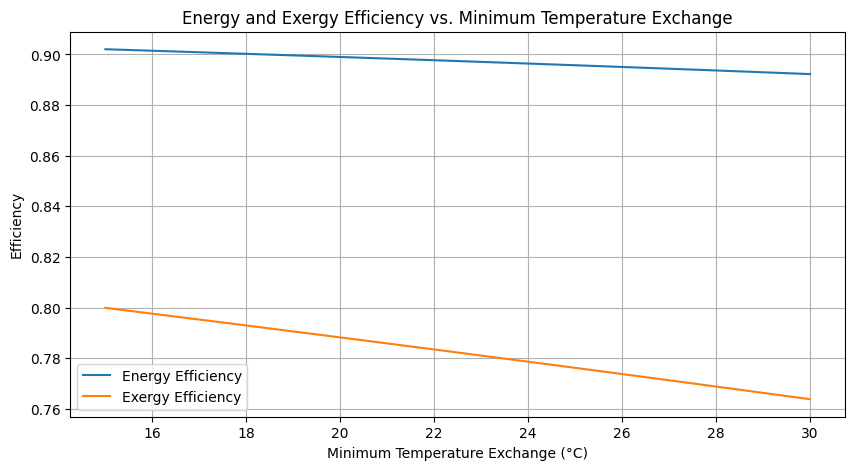

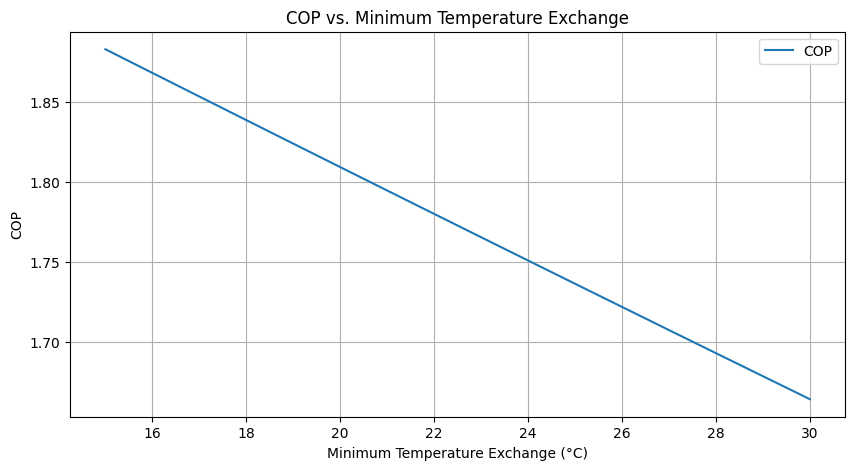

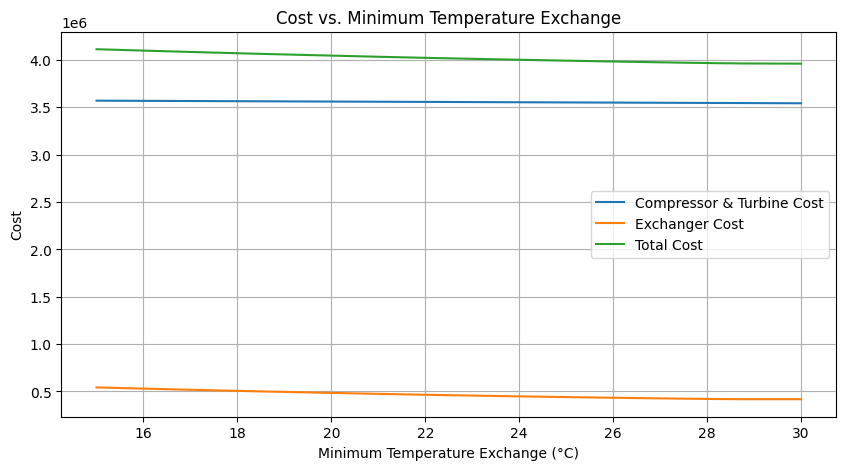

In [2]:
parameters = dict() 
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
flue_gas_composistion2 = dict()
flue_gas_composistion2["co2"] = 0.01338
flue_gas_composistion2["o2"] = 0.0384
flue_gas_composistion2["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88  #压缩机等熵效率
parameters["t_isentropic_eff_mc"] = 0.92 #透平等熵效率
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["min_temperature_exchange"] = 15 #变量1，换热器最小换热温差
parameters["industrial_waste_heat_t"] =350 #℃工业余热温度，变量3
parameters["heat_transfer_loss_eff"] = 0.96 #换热器热损失系数
parameters["t_amb"] = 20#环境温度
parameters["p_amb"] = 101325#环境压力
parameters["p_bray_L"] = 7.5e6#热泵低压
parameters["Store_electrical_power"]= 1e6

inputs={}
inputs["p_bray_H"] = 19447839.26865841#优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12827110.4341202 #优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度

# 创建一个用于存储结果的列表
results_list = []
 
# 循环遍历不同的最小换热温差
min_temp_exchange_range = np.linspace(15, 30, 26)  # 生成从15到30（包含）的25个等间距点
for min_temp_exchange in min_temp_exchange_range:
    parameters["min_temperature_exchange"] = min_temp_exchange
    
    # 实例化BraytonHeatPump并求解
    BraytonHBs = BraytonHeatPump(parameters)
    results = BraytonHBs.solve(inputs)
    
    # 存储结果
    results_list.append({
        "energy_eff": results["energy_eff"],
        "exergy_eff": results["exergy_eff"],
        "cop": results["cop"],
        "cost_comp&turb": results["cost"]["cost_comp&turb"],
        "cost_exchanger": results["cost"]["cost_exchanger"],
        "cost_all": results["cost"]["cost_all"]
    })
 
# 提取结果数据
energy_eff = [res["energy_eff"] for res in results_list]
exergy_eff = [res["exergy_eff"] for res in results_list]
cop = [res["cop"] for res in results_list]
cost_comp_turb = [res["cost_comp&turb"] for res in results_list]
cost_exchanger = [res["cost_exchanger"] for res in results_list]
cost_all = [res["cost_all"] for res in results_list]
min_temp_exchange_values = min_temp_exchange_range
 
# 绘制能量效率和㶲效率的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(min_temp_exchange_values, energy_eff, label='Energy Efficiency')
plt.plot(min_temp_exchange_values, exergy_eff, label='Exergy Efficiency')
plt.xlabel('Minimum Temperature Exchange (°C)')
plt.ylabel('Efficiency')
plt.title('Energy and Exergy Efficiency vs. Minimum Temperature Exchange')
plt.legend()
plt.grid(True)
plt.show()
 
# 绘制COP的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(min_temp_exchange_values, cop, label='COP')
plt.xlabel('Minimum Temperature Exchange (°C)')
plt.ylabel('COP')
plt.title('COP vs. Minimum Temperature Exchange')
plt.legend()
plt.grid(True)
plt.show()
 
# 绘制成本的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(min_temp_exchange_values, cost_comp_turb, label='Compressor & Turbine Cost')
plt.plot(min_temp_exchange_values, cost_exchanger, label='Exchanger Cost')
plt.plot(min_temp_exchange_values, cost_all, label='Total Cost')
plt.xlabel('Minimum Temperature Exchange (°C)')
plt.ylabel('Cost')
plt.title('Cost vs. Minimum Temperature Exchange')
plt.legend()
plt.grid(True)
plt.show()

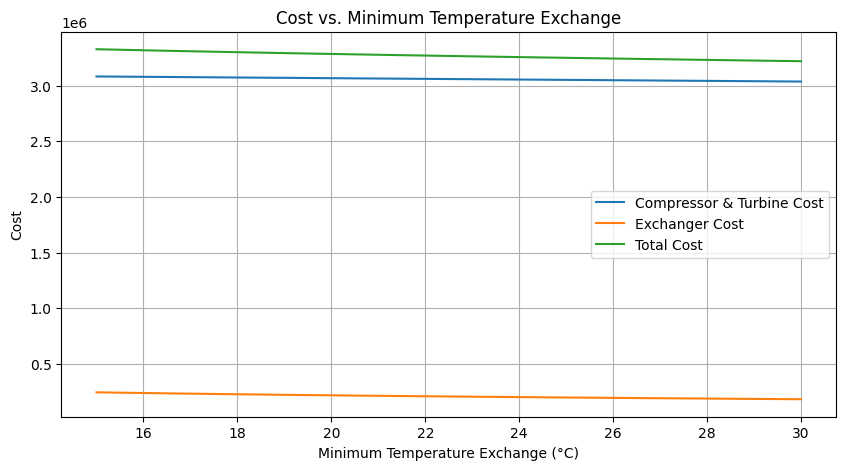

In [3]:
parameters = dict() 
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
flue_gas_composistion2 = dict()
flue_gas_composistion2["co2"] = 0.01338
flue_gas_composistion2["o2"] = 0.0384
flue_gas_composistion2["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88  #压缩机等熵效率
parameters["t_isentropic_eff_mc"] = 0.92 #透平等熵效率
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["min_temperature_exchange"] = 15 #变量1，换热器最小换热温差
parameters["industrial_waste_heat_t"] =350 #℃工业余热温度，变量3
parameters["heat_transfer_loss_eff"] = 0.96 #换热器热损失系数
parameters["t_amb"] = 20#环境温度
parameters["p_amb"] = 101325#环境压力
parameters["p_bray_L"] = 7.5e6#热泵低压
parameters["Store_electrical_power"]= 1e6

inputs={}
inputs["p_bray_H"] = 19447839.26865841#优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12827110.4341202 #优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度

# 创建一个用于存储结果的列表
results_list = []
 
# 循环遍历不同的最小换热温差
min_temp_exchange_range = np.linspace(15, 30, 26)  # 生成从15到30（包含）的25个等间距点
for min_temp_exchange in min_temp_exchange_range:
    parameters["min_temperature_exchange"] = min_temp_exchange
    
    # 实例化BraytonHeatPump并求解
    BraytonHBs = BraytonHeatPump(parameters)
    results = BraytonHBs.solve(inputs)
    
    # 存储结果
    results_list.append({
        "cost_comp&turb": results["cost2"]["cost_comp&turb"],
        "cost_exchanger": results["cost2"]["cost_exchanger"],
        "cost_all": results["cost2"]["cost_all"]
    })
 
# 提取结果数据
cost_comp_turb = [res["cost_comp&turb"] for res in results_list]
cost_exchanger = [res["cost_exchanger"] for res in results_list]
cost_all = [res["cost_all"] for res in results_list]
min_temp_exchange_values = min_temp_exchange_range

# 绘制成本的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(min_temp_exchange_values, cost_comp_turb, label='Compressor & Turbine Cost')
plt.plot(min_temp_exchange_values, cost_exchanger, label='Exchanger Cost')
plt.plot(min_temp_exchange_values, cost_all, label='Total Cost')
plt.xlabel('Minimum Temperature Exchange (°C)')
plt.ylabel('Cost')
plt.title('Cost vs. Minimum Temperature Exchange')
plt.legend()
plt.grid(True)
plt.show()

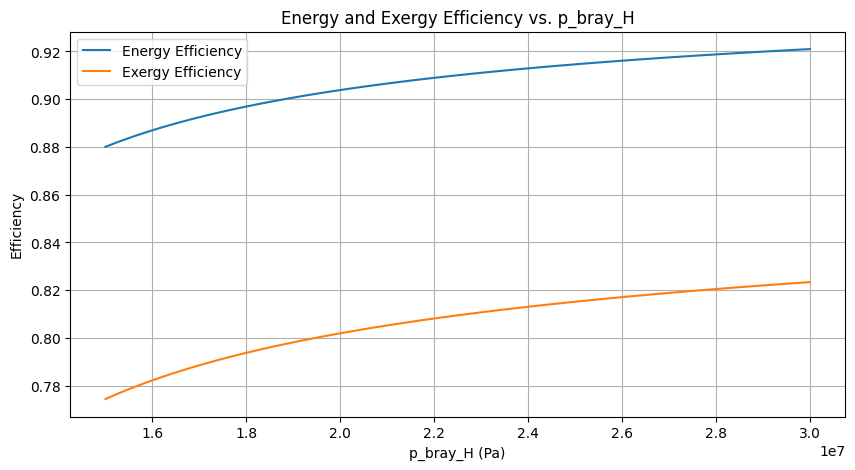

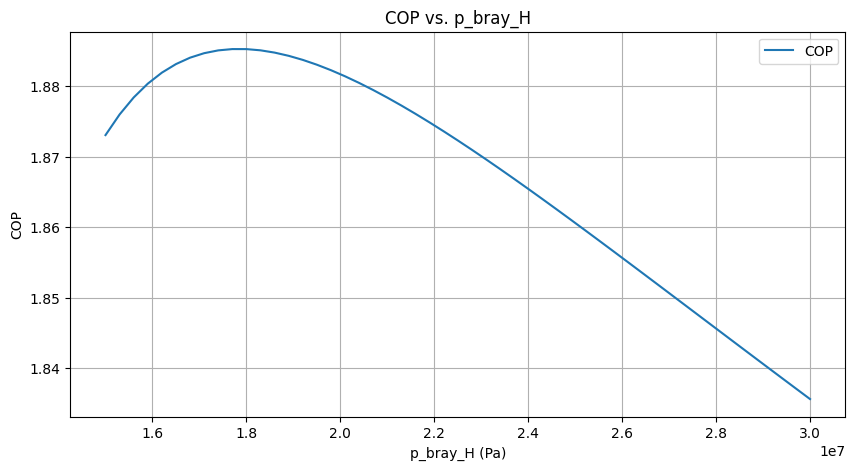

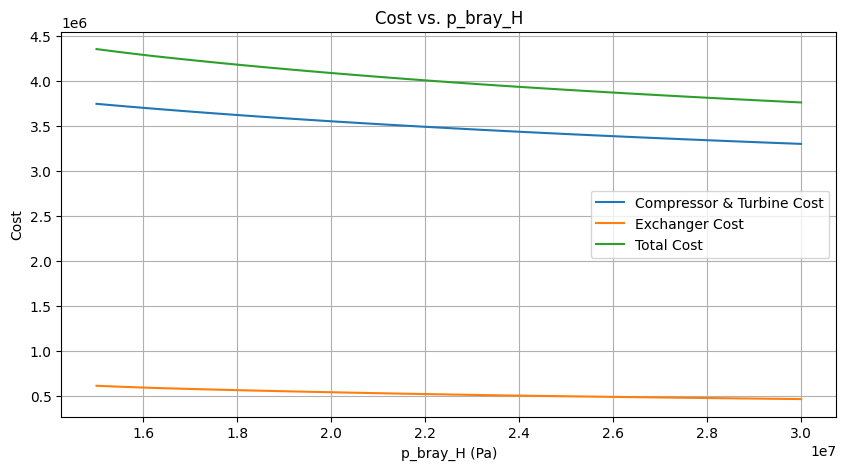

In [3]:
parameters = dict() 
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
flue_gas_composistion2 = dict()
flue_gas_composistion2["co2"] = 0.01338
flue_gas_composistion2["o2"] = 0.0384
flue_gas_composistion2["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88  #压缩机等熵效率
parameters["t_isentropic_eff_mc"] = 0.92 #透平等熵效率
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["min_temperature_exchange"] = 15 #变量1，换热器最小换热温差
parameters["industrial_waste_heat_t"] =350 #℃工业余热温度，变量3
parameters["heat_transfer_loss_eff"] = 0.96 #换热器热损失系数
parameters["t_amb"] = 20#环境温度
parameters["p_amb"] = 101325#环境压力
parameters["p_bray_L"] = 7.5e6#热泵低压
parameters["Store_electrical_power"]= 1e6

inputs={}
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度
# 创建一个用于存储结果的列表
results_list = []
 
# 循环遍历不同的p_bray_H值
p_bray_H_range = np.linspace(15e6, 30e6, 51)  # 生成从15e6到30e6的50个等间距点
for p_bray_H in p_bray_H_range:
    inputs["p_bray_H"] = p_bray_H
    r=(19447839.26865841-7.5e6)/(12827110.4341202-7.5e6)
    inputs["p_bray_M"] = ((p_bray_H-7.5e6)/r)+7.5e6  # 计算中间压力
    
    # 实例化BraytonHeatPump并求解
    BraytonHBs = BraytonHeatPump(parameters)
    results = BraytonHBs.solve(inputs)
    
    # 存储结果
    results_list.append({
        "energy_eff": results["energy_eff"],
        "exergy_eff": results["exergy_eff"],
        "cop": results["cop"],
        "cost_comp&turb": results["cost"]["cost_comp&turb"],
        "cost_exchanger": results["cost"]["cost_exchanger"],
        "cost_all": results["cost"]["cost_all"]
    })
 
# 提取结果数据
energy_eff = [res["energy_eff"] for res in results_list]
exergy_eff = [res["exergy_eff"] for res in results_list]
cop = [res["cop"] for res in results_list]
cost_comp_turb = [res["cost_comp&turb"] for res in results_list]
cost_exchanger = [res["cost_exchanger"] for res in results_list]
cost_all = [res["cost_all"] for res in results_list]
p_bray_H_values = p_bray_H_range
 
# 绘制能量效率和㶲效率的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(p_bray_H_values, energy_eff, label='Energy Efficiency')
plt.plot(p_bray_H_values, exergy_eff, label='Exergy Efficiency')
plt.xlabel('p_bray_H (Pa)')
plt.ylabel('Efficiency')
plt.title('Energy and Exergy Efficiency vs. p_bray_H')
plt.legend()
plt.grid(True)
plt.show()
 
# 绘制COP的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(p_bray_H_values, cop, label='COP')
plt.xlabel('p_bray_H (Pa)')
plt.ylabel('COP')
plt.title('COP vs. p_bray_H')
plt.legend()
plt.grid(True)
plt.show()
 
# 绘制成本的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(p_bray_H_values, cost_comp_turb, label='Compressor & Turbine Cost')
plt.plot(p_bray_H_values, cost_exchanger, label='Exchanger Cost')
plt.plot(p_bray_H_values, cost_all, label='Total Cost')
plt.xlabel('p_bray_H (Pa)')
plt.ylabel('Cost')
plt.title('Cost vs. p_bray_H')
plt.legend()
plt.grid(True)
plt.show()

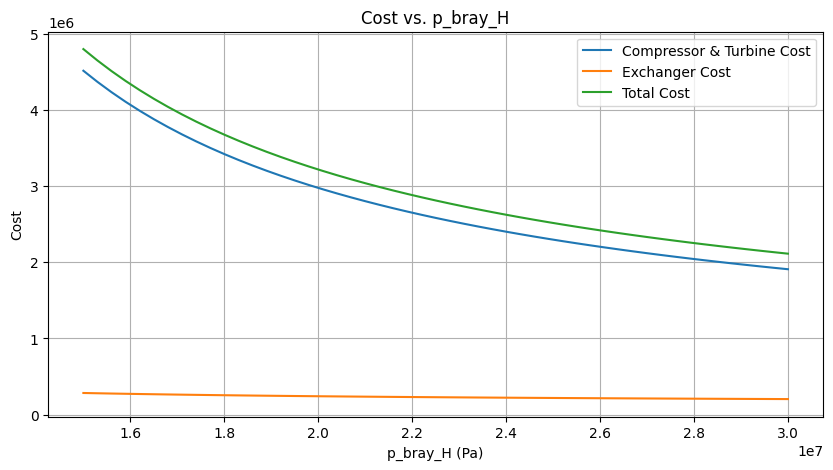

In [4]:
parameters = dict() 
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
flue_gas_composistion2 = dict()
flue_gas_composistion2["co2"] = 0.01338
flue_gas_composistion2["o2"] = 0.0384
flue_gas_composistion2["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88  #压缩机等熵效率
parameters["t_isentropic_eff_mc"] = 0.92 #透平等熵效率
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["min_temperature_exchange"] = 15 #变量1，换热器最小换热温差
parameters["industrial_waste_heat_t"] =350 #℃工业余热温度，变量3
parameters["heat_transfer_loss_eff"] = 0.96 #换热器热损失系数
parameters["t_amb"] = 20#环境温度
parameters["p_amb"] = 101325#环境压力
parameters["p_bray_L"] = 7.5e6#热泵低压
parameters["Store_electrical_power"]= 1e6

inputs={}
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度
# 创建一个用于存储结果的列表
results_list = []
 
# 循环遍历不同的p_bray_H值
p_bray_H_range = np.linspace(15e6, 30e6, 51)  # 生成从15e6到30e6的50个等间距点
for p_bray_H in p_bray_H_range:
    inputs["p_bray_H"] = p_bray_H
    r=(19447839.26865841-7.5e6)/(12827110.4341202-7.5e6)
    inputs["p_bray_M"] = ((p_bray_H-7.5e6)/r)+7.5e6  # 计算中间压力
    
    # 实例化BraytonHeatPump并求解
    BraytonHBs = BraytonHeatPump(parameters)
    results = BraytonHBs.solve(inputs)
    
    # 存储结果
    results_list.append({

        "cost_comp&turb": results["cost2"]["cost_comp&turb"],
        "cost_exchanger": results["cost2"]["cost_exchanger"],
        "cost_all": results["cost2"]["cost_all"]
    })
 
# 提取结果数据
cost_comp_turb = [res["cost_comp&turb"] for res in results_list]
cost_exchanger = [res["cost_exchanger"] for res in results_list]
cost_all = [res["cost_all"] for res in results_list]
p_bray_H_values = p_bray_H_range
 

# 绘制成本的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(p_bray_H_values, cost_comp_turb, label='Compressor & Turbine Cost')
plt.plot(p_bray_H_values, cost_exchanger, label='Exchanger Cost')
plt.plot(p_bray_H_values, cost_all, label='Total Cost')
plt.xlabel('p_bray_H (Pa)')
plt.ylabel('Cost')
plt.title('Cost vs. p_bray_H')
plt.legend()
plt.grid(True)
plt.show()

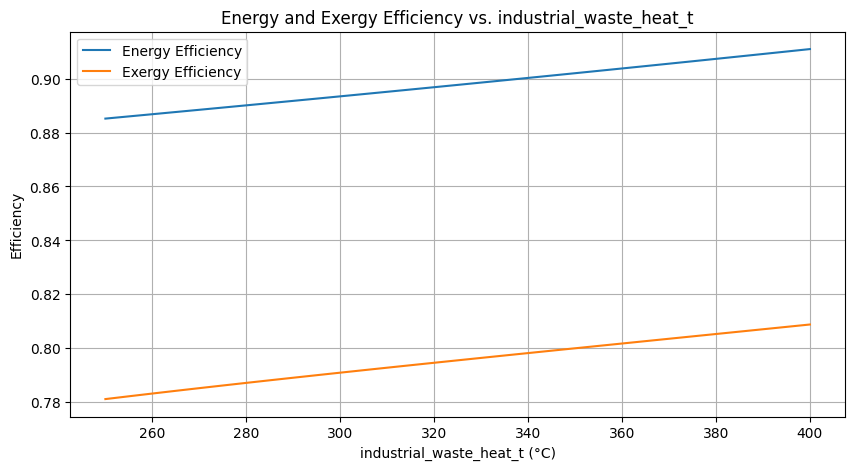

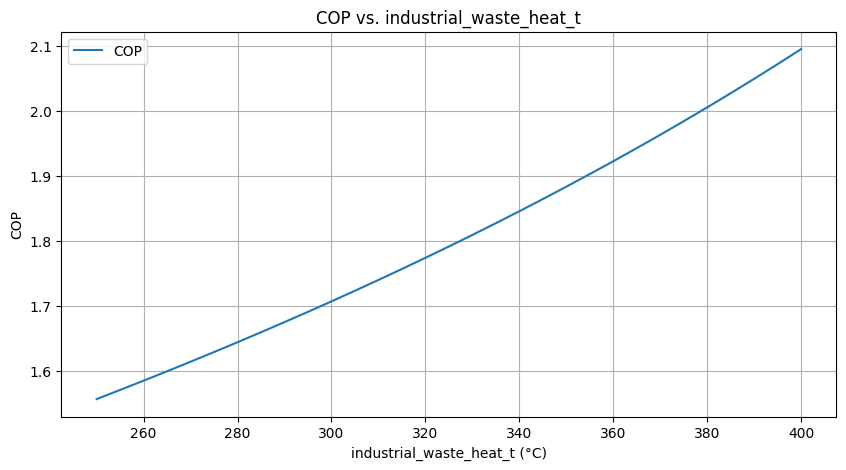

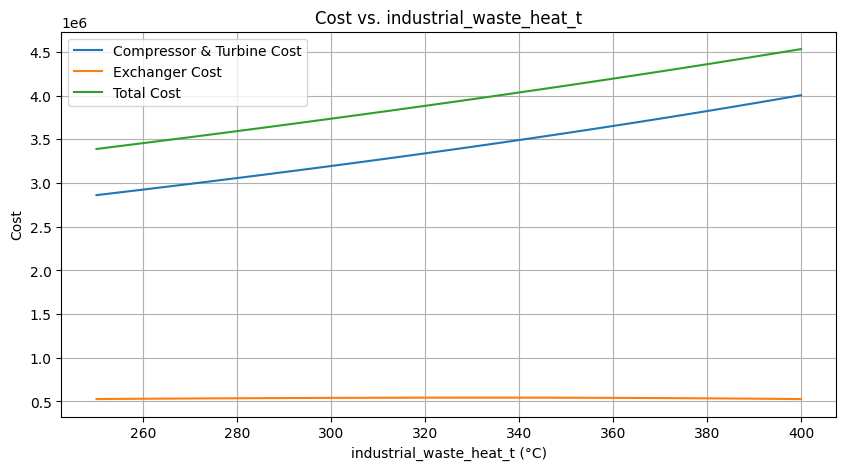

In [4]:
parameters = dict() 
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
flue_gas_composistion2 = dict()
flue_gas_composistion2["co2"] = 0.01338
flue_gas_composistion2["o2"] = 0.0384
flue_gas_composistion2["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88  #压缩机等熵效率
parameters["t_isentropic_eff_mc"] = 0.92 #透平等熵效率
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["min_temperature_exchange"] = 15 #变量1，换热器最小换热温差
parameters["industrial_waste_heat_t"] =350 #℃工业余热温度，变量3
parameters["heat_transfer_loss_eff"] = 0.96 #换热器热损失系数
parameters["t_amb"] = 20#环境温度
parameters["p_amb"] = 101325#环境压力
parameters["p_bray_L"] = 7.5e6#热泵低压
parameters["Store_electrical_power"]= 1e6

inputs={}
inputs["p_bray_H"] = 19447839.26865841#优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12827110.4341202 #优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度

# 创建一个用于存储结果的列表
results_list = []
 
# 循环遍历不同的最小换热温差
min_temp_exchange_range = np.linspace(250, 400, 31)  
for min_temp_exchange in min_temp_exchange_range:
    parameters["industrial_waste_heat_t"] = min_temp_exchange
    
    # 实例化BraytonHeatPump并求解
    BraytonHBs = BraytonHeatPump(parameters)
    results = BraytonHBs.solve(inputs)
    
    # 存储结果
    results_list.append({
        "energy_eff": results["energy_eff"],
        "exergy_eff": results["exergy_eff"],
        "cop": results["cop"],
        "cost_comp&turb": results["cost"]["cost_comp&turb"],
        "cost_exchanger": results["cost"]["cost_exchanger"],
        "cost_all": results["cost"]["cost_all"]
    })
 
# 提取结果数据
energy_eff = [res["energy_eff"] for res in results_list]
exergy_eff = [res["exergy_eff"] for res in results_list]
cop = [res["cop"] for res in results_list]
cost_comp_turb = [res["cost_comp&turb"] for res in results_list]
cost_exchanger = [res["cost_exchanger"] for res in results_list]
cost_all = [res["cost_all"] for res in results_list]
min_temp_exchange_values = min_temp_exchange_range
 
# 绘制能量效率和㶲效率的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(min_temp_exchange_values, energy_eff, label='Energy Efficiency')
plt.plot(min_temp_exchange_values, exergy_eff, label='Exergy Efficiency')
plt.xlabel('industrial_waste_heat_t (°C)')
plt.ylabel('Efficiency')
plt.title('Energy and Exergy Efficiency vs. industrial_waste_heat_t')
plt.legend()
plt.grid(True)
plt.show()
 
# 绘制COP的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(min_temp_exchange_values, cop, label='COP')
plt.xlabel('industrial_waste_heat_t (°C)')
plt.ylabel('COP')
plt.title('COP vs. industrial_waste_heat_t')
plt.legend()
plt.grid(True)
plt.show()
 
# 绘制成本的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(min_temp_exchange_values, cost_comp_turb, label='Compressor & Turbine Cost')
plt.plot(min_temp_exchange_values, cost_exchanger, label='Exchanger Cost')
plt.plot(min_temp_exchange_values, cost_all, label='Total Cost')
plt.xlabel('industrial_waste_heat_t (°C)')
plt.ylabel('Cost')
plt.title('Cost vs. industrial_waste_heat_t')
plt.legend()
plt.grid(True)
plt.show()

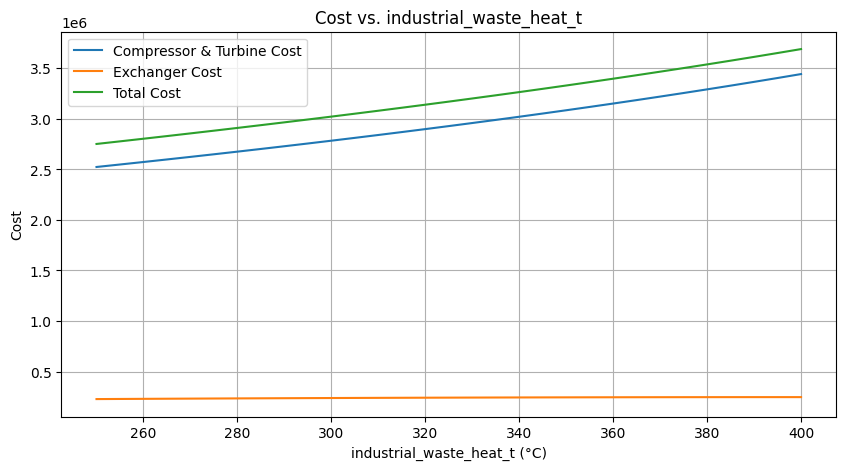

In [5]:
parameters = dict() 
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
flue_gas_composistion2 = dict()
flue_gas_composistion2["co2"] = 0.01338
flue_gas_composistion2["o2"] = 0.0384
flue_gas_composistion2["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88  #压缩机等熵效率
parameters["t_isentropic_eff_mc"] = 0.92 #透平等熵效率
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["min_temperature_exchange"] = 15 #变量1，换热器最小换热温差
parameters["industrial_waste_heat_t"] =350 #℃工业余热温度，变量3
parameters["heat_transfer_loss_eff"] = 0.96 #换热器热损失系数
parameters["t_amb"] = 20#环境温度
parameters["p_amb"] = 101325#环境压力
parameters["p_bray_L"] = 7.5e6#热泵低压
parameters["Store_electrical_power"]= 1e6

inputs={}
inputs["p_bray_H"] = 19447839.26865841#优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12827110.4341202 #优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度

# 创建一个用于存储结果的列表
results_list = []
 
# 循环遍历不同的最小换热温差
min_temp_exchange_range = np.linspace(250, 400, 31)  
for min_temp_exchange in min_temp_exchange_range:
    parameters["industrial_waste_heat_t"] = min_temp_exchange
    
    # 实例化BraytonHeatPump并求解
    BraytonHBs = BraytonHeatPump(parameters)
    results = BraytonHBs.solve(inputs)
    
    # 存储结果
    results_list.append({

        "cost_comp&turb": results["cost2"]["cost_comp&turb"],
        "cost_exchanger": results["cost2"]["cost_exchanger"],
        "cost_all": results["cost2"]["cost_all"]
    })
 
# 提取结果数据

cost_comp_turb = [res["cost_comp&turb"] for res in results_list]
cost_exchanger = [res["cost_exchanger"] for res in results_list]
cost_all = [res["cost_all"] for res in results_list]
min_temp_exchange_values = min_temp_exchange_range
 
# 绘制成本的变化曲线
plt.figure(figsize=(10, 5))
plt.plot(min_temp_exchange_values, cost_comp_turb, label='Compressor & Turbine Cost')
plt.plot(min_temp_exchange_values, cost_exchanger, label='Exchanger Cost')
plt.plot(min_temp_exchange_values, cost_all, label='Total Cost')
plt.xlabel('industrial_waste_heat_t (°C)')
plt.ylabel('Cost')
plt.title('Cost vs. industrial_waste_heat_t')
plt.legend()
plt.grid(True)
plt.show()